In [10]:
import pandas as pd

# Memanggil dataset bersih dari folder 01-Data-Preprocessing
path_data = '../01-Data-Preprocessing/jdm_used_cars_cleaned.csv'
df = pd.read_csv(path_data)

print("Dataset bersih berhasil di-load ke Fase 2!")
display(df.head())

Dataset bersih berhasil di-load ke Fase 2!


,price,year,mileage,engine_capacity,mark_bmw,mark_chrysler,mark_citroen,mark_daihatsu,mark_ford,mark_gm,...,transmission_cvt,transmission_mt,drive_4wd,drive_awd,hand_drive_lhd,hand_drive_rhd,fuel_diesel,fuel_gasoline,fuel_hybrid,fuel_lpg
0,165,-0.260302,-1.182687,0.916686,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,190,0.555838,0.846600,0.898281,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
2,190,0.011745,-0.727528,-1.549646,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False
3,190,-0.532349,-0.358215,-1.549646,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False
4,220,1.099932,0.512482,-0.555751,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False


In [11]:
# Target (y) adalah kolom harga
y = df['price']

# Fitur (X) adalah seluruh kolom KECUALI kolom harga
X = df.drop(columns=['price'])

print(f"Dimensi Fitur (X): {X.shape}")
print(f"Dimensi Target (y): {y.shape}")

Dimensi Fitur (X): (2270, 39)
Dimensi Target (y): (2270,)


In [12]:
from sklearn.model_selection import train_test_split

# Memotong data dengan rasio 80:20
# random_state=42 digunakan agar potongan datanya selalu sama setiap kali kode di-run (reproducible)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Laporan Train-Test Split ---")
print(f"Total data asli       : {len(df)} baris")
print(f"Data Latihan (X_train): {len(X_train)} baris (80%) -> Untuk belajar")
print(f"Data Ujian (X_test)   : {len(X_test)} baris (20%) -> Untuk evaluasi nanti")

--- Laporan Train-Test Split ---
Total data asli       : 2270 baris
Data Latihan (X_train): 1816 baris (80%) -> Untuk belajar
Data Ujian (X_test)   : 454 baris (20%) -> Untuk evaluasi nanti


In [13]:
from sklearn.linear_model import LinearRegression

# 1. Mengaktifkan (Inisialisasi) Algoritma
model_lr = LinearRegression()

# 2. Proses Belajar (Training)
# Menyuapkan data latih ke dalam model
model_lr.fit(X_train, y_train)

print("✅ Model Linear Regression berhasil dilatih! (Training Selesai)")

✅ Model Linear Regression berhasil dilatih! (Training Selesai)


In [14]:
# 1. Meminta model menebak harga dari data ujian
y_pred = model_lr.predict(X_test)

# 2. Membuat tabel perbandingan (Harga Asli vs Harga Tebakan)
komparasi = pd.DataFrame({
    'Harga Asli (Real)': y_test,
    'Tebakan Model (Prediksi)': y_pred
})

# Membulatkan hasil tebakan agar lebih enak dibaca
komparasi['Tebakan Model (Prediksi)'] = komparasi['Tebakan Model (Prediksi)'].round(0)

# Menghitung selisih (Error)
komparasi['Selisih Error'] = abs(komparasi['Harga Asli (Real)'] - komparasi['Tebakan Model (Prediksi)'])

# Menampilkan 5 sampel acak dari hasil ujian
print("--- Hasil Ujian Model (Sampel) ---")
display(komparasi.sample(5, random_state=42))

--- Hasil Ujian Model (Sampel) ---


,Harga Asli (Real),Tebakan Model (Prediksi),Selisih Error
719,840,983.0,143.0
1956,1306,1058.0,248.0
324,625,758.0,133.0
916,924,1108.0,184.0
643,800,1017.0,217.0


In [15]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Menghitung R-Squared (R2)
nilai_r2 = r2_score(y_test, y_pred)

# 2. Menghitung RMSE (akar kuadrat dari Mean Squared Error)
nilai_mse = mean_squared_error(y_test, y_pred)
nilai_rmse = np.sqrt(nilai_mse)

print("🎓 --- Rapor Performa Model Linear Regression --- 🎓")
print(f"Skor R-Squared (R2) : {nilai_r2:.4f} (atau {nilai_r2 * 100:.2f}%)")
print(f"Skor RMSE           : {nilai_rmse:.2f}")

🎓 --- Rapor Performa Model Linear Regression --- 🎓
Skor R-Squared (R2) : 0.1382 (atau 13.82%)
Skor RMSE           : 269.84


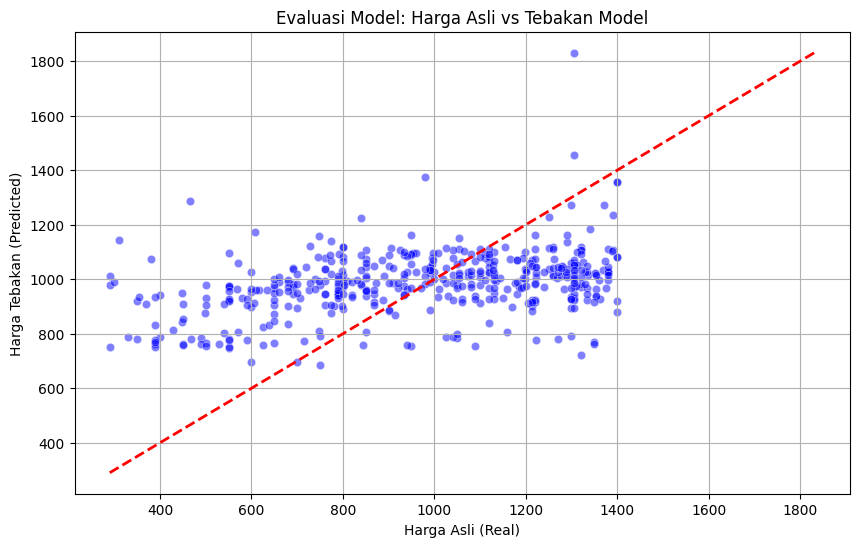

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Membuat titik-titik persebaran (Sumbu X: Asli, Sumbu Y: Tebakan)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='blue')

# Membuat garis referensi ideal (Garis diagonal sempurna)
# Jika tebakan 100% benar, semua titik akan berada persis di atas garis merah ini
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

plt.title('Evaluasi Model: Harga Asli vs Tebakan Model')
plt.xlabel('Harga Asli (Real)')
plt.ylabel('Harga Tebakan (Predicted)')
plt.grid(True)
plt.show()

In [17]:
from sklearn.ensemble import RandomForestRegressor

# 1. Inisialisasi Algoritma (Memanggil 100 "pohon ahli" / estimators)
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Proses Belajar (Training) menggunakan data yang sama
model_rf.fit(X_train, y_train)

# 3. Menyuruh 100 ahli tersebut menebak soal ujian
y_pred_rf = model_rf.predict(X_test)

print("🌳 Model Random Forest (100 Decision Trees) berhasil dilatih! 🌳")

🌳 Model Random Forest (100 Decision Trees) berhasil dilatih! 🌳


In [18]:
# Menghitung ulang Rapor khusus untuk Random Forest
nilai_r2_rf = r2_score(y_test, y_pred_rf)
nilai_rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("🏆 --- KOMPARASI RAPOR MODEL --- 🏆\n")

print("1. LINEAR REGRESSION (Baseline)")
print(f"   Skor R2   : {nilai_r2:.4f}")
print(f"   Skor RMSE : {nilai_rmse:.2f}\n")

print("2. RANDOM FOREST (Upgrade)")
print(f"   Skor R2   : {nilai_r2_rf:.4f}")
print(f"   Skor RMSE : {nilai_rmse_rf:.2f}\n")

# Menghitung selisih peningkatan
peningkatan_r2 = (nilai_r2_rf - nilai_r2) * 100
print(f"🚀 Kesimpulan: Random Forest mengubah akurasi sebesar {peningkatan_r2:.2f}%!")

🏆 --- KOMPARASI RAPOR MODEL --- 🏆

1. LINEAR REGRESSION (Baseline)
   Skor R2   : 0.1382
   Skor RMSE : 269.84

2. RANDOM FOREST (Upgrade)
   Skor R2   : 0.2181
   Skor RMSE : 257.02

🚀 Kesimpulan: Random Forest mengubah akurasi sebesar 7.99%!
